<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/week5_vaishnavi_deshmukh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Text Generation using Vanilla RNN, LSTM and GRU

###Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0




###Load Text Corpus

In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



###Tokenization & Sequence Creation

In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(sequence) for sequence in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 37
Input Shape: (35, 7)
Output Shape: (35,)


###Vanilla RNN Model

In [4]:
rnn_model = Sequential([

    Embedding(total_words, 32, input_length=max_len-1),

    SimpleRNN(64),

    Dense(total_words, activation="softmax")

])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

print("Vanilla RNN Training Completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN Training Completed


###LSTM Model

In [5]:
lstm_model = Sequential([

    Embedding(total_words, 32, input_length=max_len-1),

    LSTM(64),

    Dense(total_words, activation="softmax")

])

lstm_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

lstm_history = lstm_model.fit(

    X,

    y,

    epochs=100,

    verbose=0

)

print("LSTM Training Completed")

LSTM Training Completed


###GRU Model

In [6]:
gru_model = Sequential([

    Embedding(total_words,32,input_length=max_len-1),

    GRU(64),

    Dense(total_words,activation="softmax")

])

gru_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

gru_history = gru_model.fit(

    X,

    y,

    epochs=100,

    verbose=0

)

print("GRU Training Completed")

GRU Training Completed


###Compare Training Loss

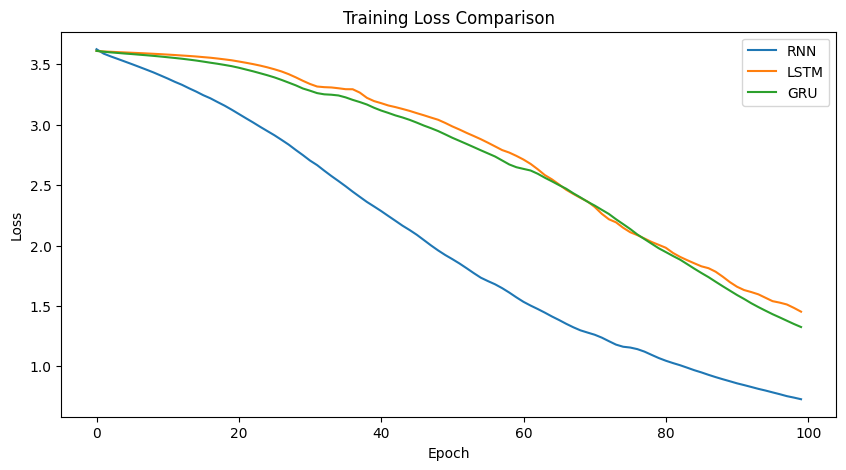

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history["loss"],
    label="RNN"
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM"
)

plt.plot(
    gru_history.history["loss"],
    label="GRU"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.show()

###Text Generation Function

In [8]:
def generate_text(model, seed_text, next_words=5):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding="pre"
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word

                break

        seed_text += " " + output_word

    return seed_text

###Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))

print("LSTM:", generate_text(lstm_model, "deep learning", 5))

print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models models generate meaningful sentences
GRU : deep learning models networks are for for


Generated text from the LSTM and GRU models is generally more meaningful and coherent than the Vanilla RNN because they are better at learning long-term dependencies.

###Model Evaluation

In [10]:
rnn_loss, rnn_acc = rnn_model.evaluate(X, y, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X, y, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(X, y, verbose=0)

print("RNN Accuracy :", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy :", gru_acc)

RNN Accuracy : 0.9142857193946838
LSTM Accuracy: 0.6571428775787354
GRU Accuracy : 0.7142857313156128


###Model Comparison Table





In [11]:
comparison = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Accuracy": [rnn_acc, lstm_acc, gru_acc],
    "Loss": [rnn_loss, lstm_loss, gru_loss]
})

comparison

,Model,Accuracy,Loss
0,Vanilla RNN,0.914286,0.714707
1,LSTM,0.657143,1.441527
2,GRU,0.714286,1.300198


###Accuracy Comparison Graph

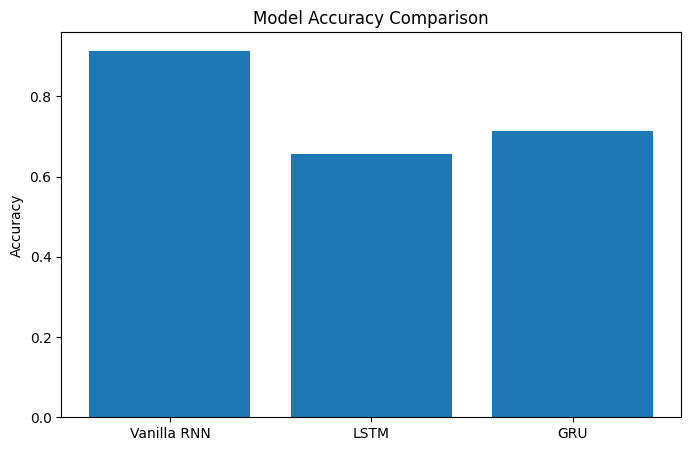

In [12]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

###Conclusion

This project successfully implemented text generation using Vanilla RNN, LSTM, and GRU models. The Vanilla RNN learned basic sequential patterns but struggled with long-term dependencies. LSTM generated more coherent and context-aware text due to its memory gates, while GRU achieved comparable performance with a simpler and faster architecture. The comparison shows that gated recurrent networks (LSTM and GRU) are more effective than Vanilla RNN for text generation tasks.